In [1]:
import pandas as pd
sf_df = pd.read_parquet("/kaggle/input/datasets/kylenaluan/session-features/session_features.parquet")

In [2]:
abandoned=sf_df[sf_df['cart_abandoned']==True]



In [3]:
bought=sf_df[sf_df['converted']==True]

We now have data of all sessions where nothing was purchased after being put in the cart and the ones where something was purchased. Is there anything that stands out about sessions where the cart is abandoned? We will look at duration of session, unique number of products interacted with, number of items viewed, number of items carted, and the day of the week and time of both categories.

In [4]:
print("BOUGHT DESCRIPTIVE STATS")
print(bought[['duration_seconds', 'unique_products', 'n_views', 'n_carts']].describe())

print("\nABANDONED DESCRIPTIVE STATS")
print(abandoned[['duration_seconds', 'unique_products', 'n_views', 'n_carts']].describe())

BOUGHT DESCRIPTIVE STATS
       duration_seconds  unique_products       n_views       n_carts
count      1.402758e+06     1.402758e+06  1.402758e+06  1.402758e+06
mean       7.065735e+02     3.010560e+00  5.813002e+00  1.160729e+00
std        1.455834e+04     4.432403e+00  8.604102e+00  1.497555e+00
min        0.000000e+00     1.000000e+00  0.000000e+00  0.000000e+00
25%        1.260000e+02     1.000000e+00  2.000000e+00  0.000000e+00
50%        2.570000e+02     2.000000e+00  3.000000e+00  1.000000e+00
75%        5.620000e+02     3.000000e+00  6.000000e+00  2.000000e+00
max        4.429727e+06     2.440000e+02  4.160000e+02  2.500000e+02

ABANDONED DESCRIPTIVE STATS
       duration_seconds  unique_products       n_views       n_carts
count      1.376212e+06     1.376212e+06  1.376212e+06  1.376212e+06
mean       8.660675e+02     4.047279e+00  7.786080e+00  1.598756e+00
std        1.635534e+04     6.025420e+00  1.136181e+01  1.483091e+00
min        0.000000e+00     1.000000e+00  0.00000

# Duration of Session

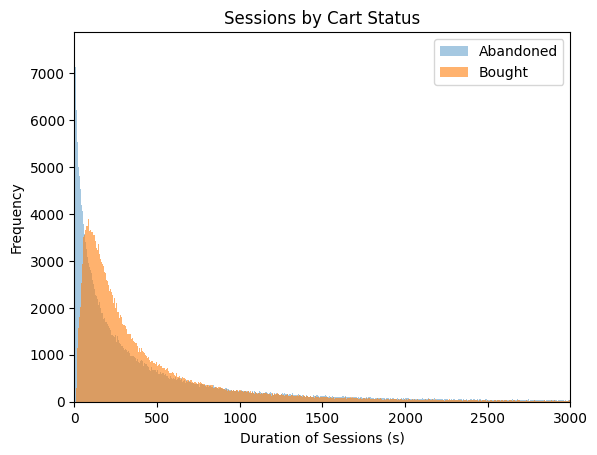

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.xlim(0, 3000)
plt.hist(abandoned['duration_seconds'],  bins=range(0, 3000), alpha=0.4, label='Abandoned')
plt.hist(bought['duration_seconds'],  bins=range(0, 3000), alpha=0.6, label='Bought')

plt.title("Sessions by Cart Status")
plt.xlabel("Duration of Sessions (s)")
plt.ylabel("Frequency")

plt.legend()

plt.show()

# Unique Products Interacted With

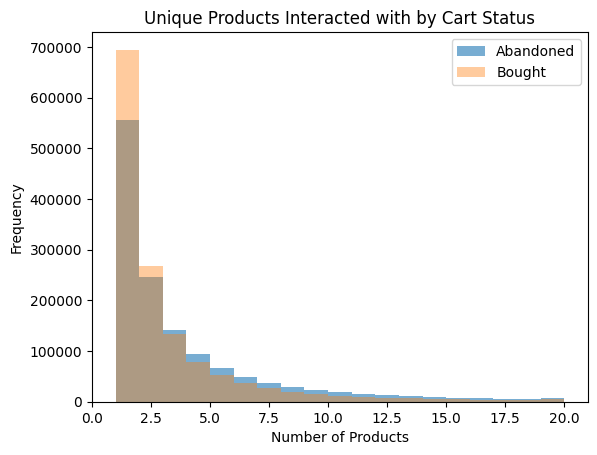

In [6]:
plt.figure()
plt.xlim(0, 21)
plt.hist(abandoned['unique_products'], bins=range(0, 21), alpha=0.6, label='Abandoned')
plt.hist(bought['unique_products'], bins=range(0, 21), alpha=0.4, label='Bought')

plt.title("Unique Products Interacted with by Cart Status")
plt.xlabel("Number of Products")
plt.ylabel("Frequency")

plt.legend()

plt.show()

# Number of Items Viewed

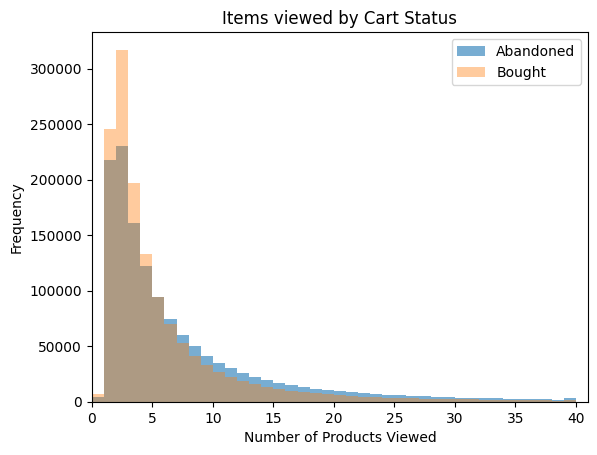

In [7]:
plt.figure()
plt.xlim(0, 41)
plt.hist(abandoned['n_views'], bins=range(0, 41), alpha=0.6, label='Abandoned')
plt.hist(bought['n_views'], bins=range(0, 41), alpha=0.4, label='Bought')

plt.title("Items viewed by Cart Status")
plt.xlabel("Number of Products Viewed")
plt.ylabel("Frequency")

plt.legend()

plt.show()

# Number of Items Carted

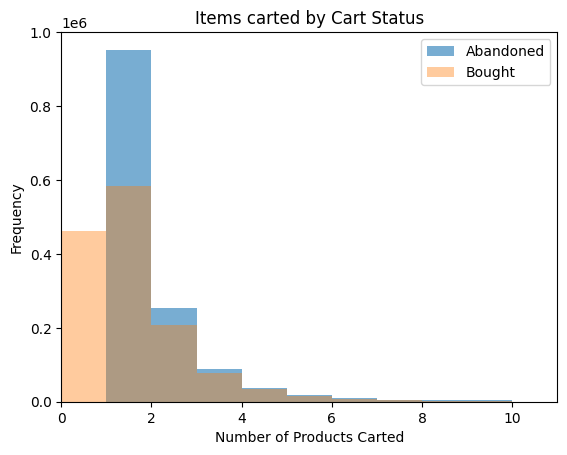

In [8]:
plt.figure()
plt.xlim(0, 11)
plt.hist(abandoned['n_carts'], bins=range(0, 11), alpha=0.6, label='Abandoned')
plt.hist(bought['n_carts'], bins=range(0, 11), alpha=0.4, label='Bought')

plt.title("Items carted by Cart Status")
plt.xlabel("Number of Products Carted")
plt.ylabel("Frequency")

plt.legend()

plt.show()

# Hour and Day of the Week

In [9]:
day_map = {
    'Monday': 0,
    'Tuesday': 24,
    'Wednesday': 48,
    'Thursday': 72,
    'Friday': 96,
    'Saturday': 120,
    'Sunday': 144
}

bought['day_numeric'] = bought['day_of_week'].map(day_map)
bought['hour_of_week'] = bought['day_numeric'] + bought['hour_of_day']
abandoned['day_numeric'] = abandoned['day_of_week'].map(day_map)
abandoned['hour_of_week'] = abandoned['day_numeric'] + abandoned['hour_of_day']

/tmp/ipykernel_16/3548148639.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bought['day_numeric'] = bought['day_of_week'].map(day_map)
/tmp/ipykernel_16/3548148639.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bought['hour_of_week'] = bought['day_numeric'] + bought['hour_of_day']
/tmp/ipykernel_16/3548148639.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

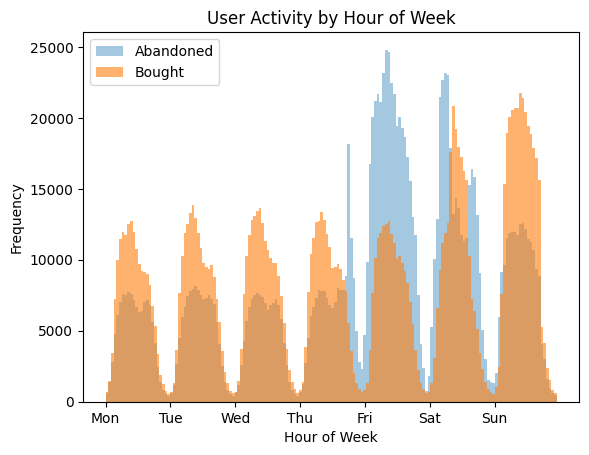

In [10]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(abandoned['hour_of_week'], bins=168, alpha=0.4, label='Abandoned')
plt.hist(bought['hour_of_week'], bins=168, alpha=0.6, label='Bought')

plt.title("User Activity by Hour of Week")
plt.xlabel("Hour of Week")
plt.ylabel("Frequency")

plt.legend()

plt.xticks(
    ticks=[0, 24, 48, 72, 96, 120, 144],
    labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

plt.show()